In [1]:
import polars as pl
import pandas as pd
from src.globals import AAPL_DATA_PATH, LOBSTER_MULTIPLIER

In [2]:
AAPL_raw = pl.read_csv(f"../{AAPL_DATA_PATH}").to_pandas()

In [8]:
AAPL_raw.columns = [str(i) for i in range(len(AAPL_raw.columns))]
AAPL_raw['daily_risk_free'] = 0
AAPL_raw['midprice'] = (AAPL_raw['1'] + AAPL_raw['3']) / (2 * LOBSTER_MULTIPLIER)
AAPL_raw['bid'] = AAPL_raw['1'] / LOBSTER_MULTIPLIER
AAPL_raw['ask'] = AAPL_raw['3'] / LOBSTER_MULTIPLIER
AAPL = AAPL_raw[['midprice', 'bid', 'ask', 'daily_risk_free']]
AAPL.to_csv('../data/deepLOB/AAPL_transformed.csv')

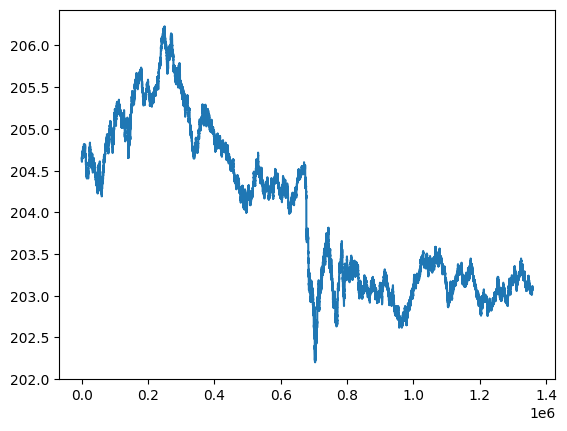

In [9]:
import matplotlib.pyplot as plt

plt.plot(AAPL['midprice'])